# Cell Type Composition Along the Gut Axis

This notebook analyzes cell type composition across different gut segments (tissues) for each lineage in the healthy gut atlas data.

The healthy gut atlas provides **full intestinal coverage** from duodenum to rectum with **consistent cell type labeling** across all segments. This dataset enables us to:

1. **Track composition changes along the entire gut axis**
2. **Compare across lineages**
3. **Control for technical variation** - By including assay, sample collection method, and other covariates, we can distinguish biological from technical effects

This analysis would not be possible without both the comprehensive tissue sampling, harmonized cell type annotations and harmonized clinical data across all datasets.

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Set scanpy settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white')

# Create output directory
output_dir = Path('/Users/kylekimler/GCA/github_vignette_output')
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {output_dir}")

Output directory: /Users/kylekimler/GCA/github_vignette_output


## Load Data by Lineage

In [9]:
print(*adata.obs['tissue'].unique())

gastrointestinal_system_mesentery ascending_colon ileum rectum small_intestine colon duodenum descending_colon sigmoid_colon vermiform_appendix jejunum


In [10]:
# Define lineage paths
lineage_paths = {
    'stroma': '/Users/kylekimler/Projects/GCA/meta_datasets/integrated-objects/stroma.h5ad',
    'epithelial': '/Users/kylekimler/Projects/GCA/meta_datasets/integrated-objects/epithelial.h5ad',
    'lymphoid': '/Users/kylekimler/Projects/GCA/meta_datasets/integrated-objects/lymphoid.h5ad',
    'myeloid': '/Users/kylekimler/Projects/GCA/meta_datasets/integrated-objects/myeloid.h5ad'
}

# Define tissues to keep
tissues_keep = [
    "gastrointestinal_system_mesentery",
    "ascending_colon",
    "ileum",
    "vermiform_appendix",
    "rectum",
    "small_intestine",
    "duodenum",
    "colon",
    "descending_colon",
    "sigmoid_colon",
    "jejunum"
]

# Define tissue order along the gut axis
tissue_order = [
    "duodenum",
    "jejunum", 
    "ileum",
    "vermiform_appendix",
    "small_intestine",
    "ascending_colon",
    "descending_colon",
    "sigmoid_colon",
    "colon",
    "rectum",
    "gastrointestinal_system_mesentery"
]

# Create tissue order mapping
tissue_to_order = {tissue: idx for idx, tissue in enumerate(tissue_order)}

# Load and filter each lineage
lineages = {}
for lineage_name, path in lineage_paths.items():
    print(f"\nLoading {lineage_name}...")
    adata = sc.read_h5ad(path)
    
    # Add tissue order
    adata.obs['tissue_order'] = adata.obs['tissue'].map(tissue_to_order)
    adata.obs['tissue_order'] = adata.obs['tissue_order'].fillna(999)
    
    lineages[lineage_name] = adata
    print(f"  Cell types: {adata.obs['hgca_celltype_v1'].nunique()}")


Loading stroma...
  Cell types: 35

Loading epithelial...
  Cell types: 30

Loading lymphoid...
  Cell types: 35

Loading myeloid...
  Cell types: 12


In [13]:
# Check sample keys for each lineage
sample_keys = {}
for lineage_name, adata in lineages.items():
    sample_key = "sample_id"
    sample_keys[lineage_name] = sample_key
    print(f"  Unique {sample_key}s for {lineage_name}: {adata.obs[sample_key].nunique()}")

  Unique sample_ids for stroma: 217
  Unique sample_ids for epithelial: 371
  Unique sample_ids for lymphoid: 454
  Unique sample_ids for myeloid: 357


## Compute Coverage Tables

Calculate number of cells, samples, and donors by tissue and assay for each lineage.

In [14]:
# Compute coverage tables for each lineage
coverage_tables = {}

for lineage_name, adata in lineages.items():
    print(f"\nComputing coverage for {lineage_name}...")
    
    sample_key = sample_keys[lineage_name]
    
    # Coverage by tissue
    coverage_tissue = adata.obs.groupby('tissue').agg({
        'tissue': 'count',  # number of cells
        sample_key: 'nunique',  # number of samples
    }).rename(columns={'tissue': 'n_cells'})
    
    # Coverage by tissue and assay
    coverage_tissue_assay = adata.obs.groupby(['tissue', 'assay']).agg({
        'tissue': 'count',
        sample_key: 'nunique',
    }).rename(columns={'tissue': 'n_cells'})
    
    # Add donor counts if available
    if 'donor_id' in adata.obs.columns:
        coverage_tissue['n_donors'] = adata.obs.groupby('tissue')['donor_id'].nunique()
        coverage_tissue_assay['n_donors'] = adata.obs.groupby(['tissue', 'assay'])['donor_id'].nunique()
    
    coverage_tables[lineage_name] = {
        'by_tissue': coverage_tissue,
        'by_tissue_assay': coverage_tissue_assay
    }
    
    print(f"  Coverage by tissue:")
    print(coverage_tissue)
    
    # Save coverage tables
    coverage_tissue.to_csv(output_dir / f'{lineage_name}_coverage_by_tissue.csv')
    coverage_tissue_assay.to_csv(output_dir / f'{lineage_name}_coverage_by_tissue_assay.csv')


Computing coverage for stroma...
  Coverage by tissue:
                                   n_cells  sample_id  n_donors
tissue                                                         
ascending_colon                      10463         37        34
caecum                                1190          8         6
colon                                10369         10        10
descending_colon                       140          4         3
duodenum                               224          5         3
gastrointestinal_system_mesentery      226          5         5
ileum                                24287        113        78
jejunum                                276          3         2
rectum                                2299          4         3
sigmoid_colon                         1949         13         8
small_intestine                          5          1         1
transverse_colon                      1209          9         6
vermiform_appendix                     244      

## Compute Per-Sample Cell Type Fractions with CLR Transformation

Calculate cell type fractions for each sample and apply centered log-ratio (CLR) transformation to handle compositional data.

In [15]:
def compute_clr_composition(adata, sample_key, pseudocount=0.5):
    """
    Compute per-sample cell type fractions and apply CLR transformation.
    
    CLR (centered log-ratio) transformation is appropriate for compositional data
    as it accounts for the constraint that proportions sum to 1.
    """
    # Count cells per sample and cell type
    counts = pd.crosstab(
        adata.obs[sample_key],
        adata.obs['Prelim annotation']
    )
    
    # Add pseudocount and normalize to proportions
    x = counts.astype(float) + pseudocount
    proportions = x.div(x.sum(axis=1), axis=0)
    
    # Apply CLR transformation: log(x) - mean(log(x))
    logx = np.log(proportions.values)
    clr = logx - logx.mean(axis=1, keepdims=True)
    
    clr_df = pd.DataFrame(
        clr,
        index=proportions.index,
        columns=proportions.columns
    )
    
    # Also return raw proportions
    return clr_df, proportions

# Compute compositions for each lineage
compositions = {}

for lineage_name, adata in lineages.items():
    print(f"\nComputing composition for {lineage_name}...")
    sample_key = sample_keys[lineage_name]
    
    clr_df, prop_df = compute_clr_composition(adata, sample_key)
    
    # Add metadata
    sample_metadata = adata.obs.groupby(sample_key).agg({
        'tissue': 'first',
        'tissue_order': 'first',
        'assay': 'first',
        'sampled_site_condition': lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan,
        'radial_tissue_term': lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan,
        'sample_collection_method': lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan,
    }).reset_index()
    
    compositions[lineage_name] = {
        'clr': clr_df,
        'proportions': prop_df,
        'metadata': sample_metadata
    }
    
    print(f"  Samples: {len(clr_df)}")
    print(f"  Cell types: {len(clr_df.columns)}")
    
    # Save compositions
    clr_df.to_csv(output_dir / f'{lineage_name}_clr_composition.csv')
    prop_df.to_csv(output_dir / f'{lineage_name}_proportions.csv')
    sample_metadata.to_csv(output_dir / f'{lineage_name}_sample_metadata.csv', index=False)


Computing composition for stroma...
  Samples: 217
  Cell types: 35

Computing composition for epithelial...
  Samples: 371
  Cell types: 30

Computing composition for lymphoid...
  Samples: 454
  Cell types: 35

Computing composition for myeloid...
  Samples: 357
  Cell types: 12


## Visualize Composition Trajectories

Create line plots showing composition changes along the tissue axis for top cell types and major lineages.

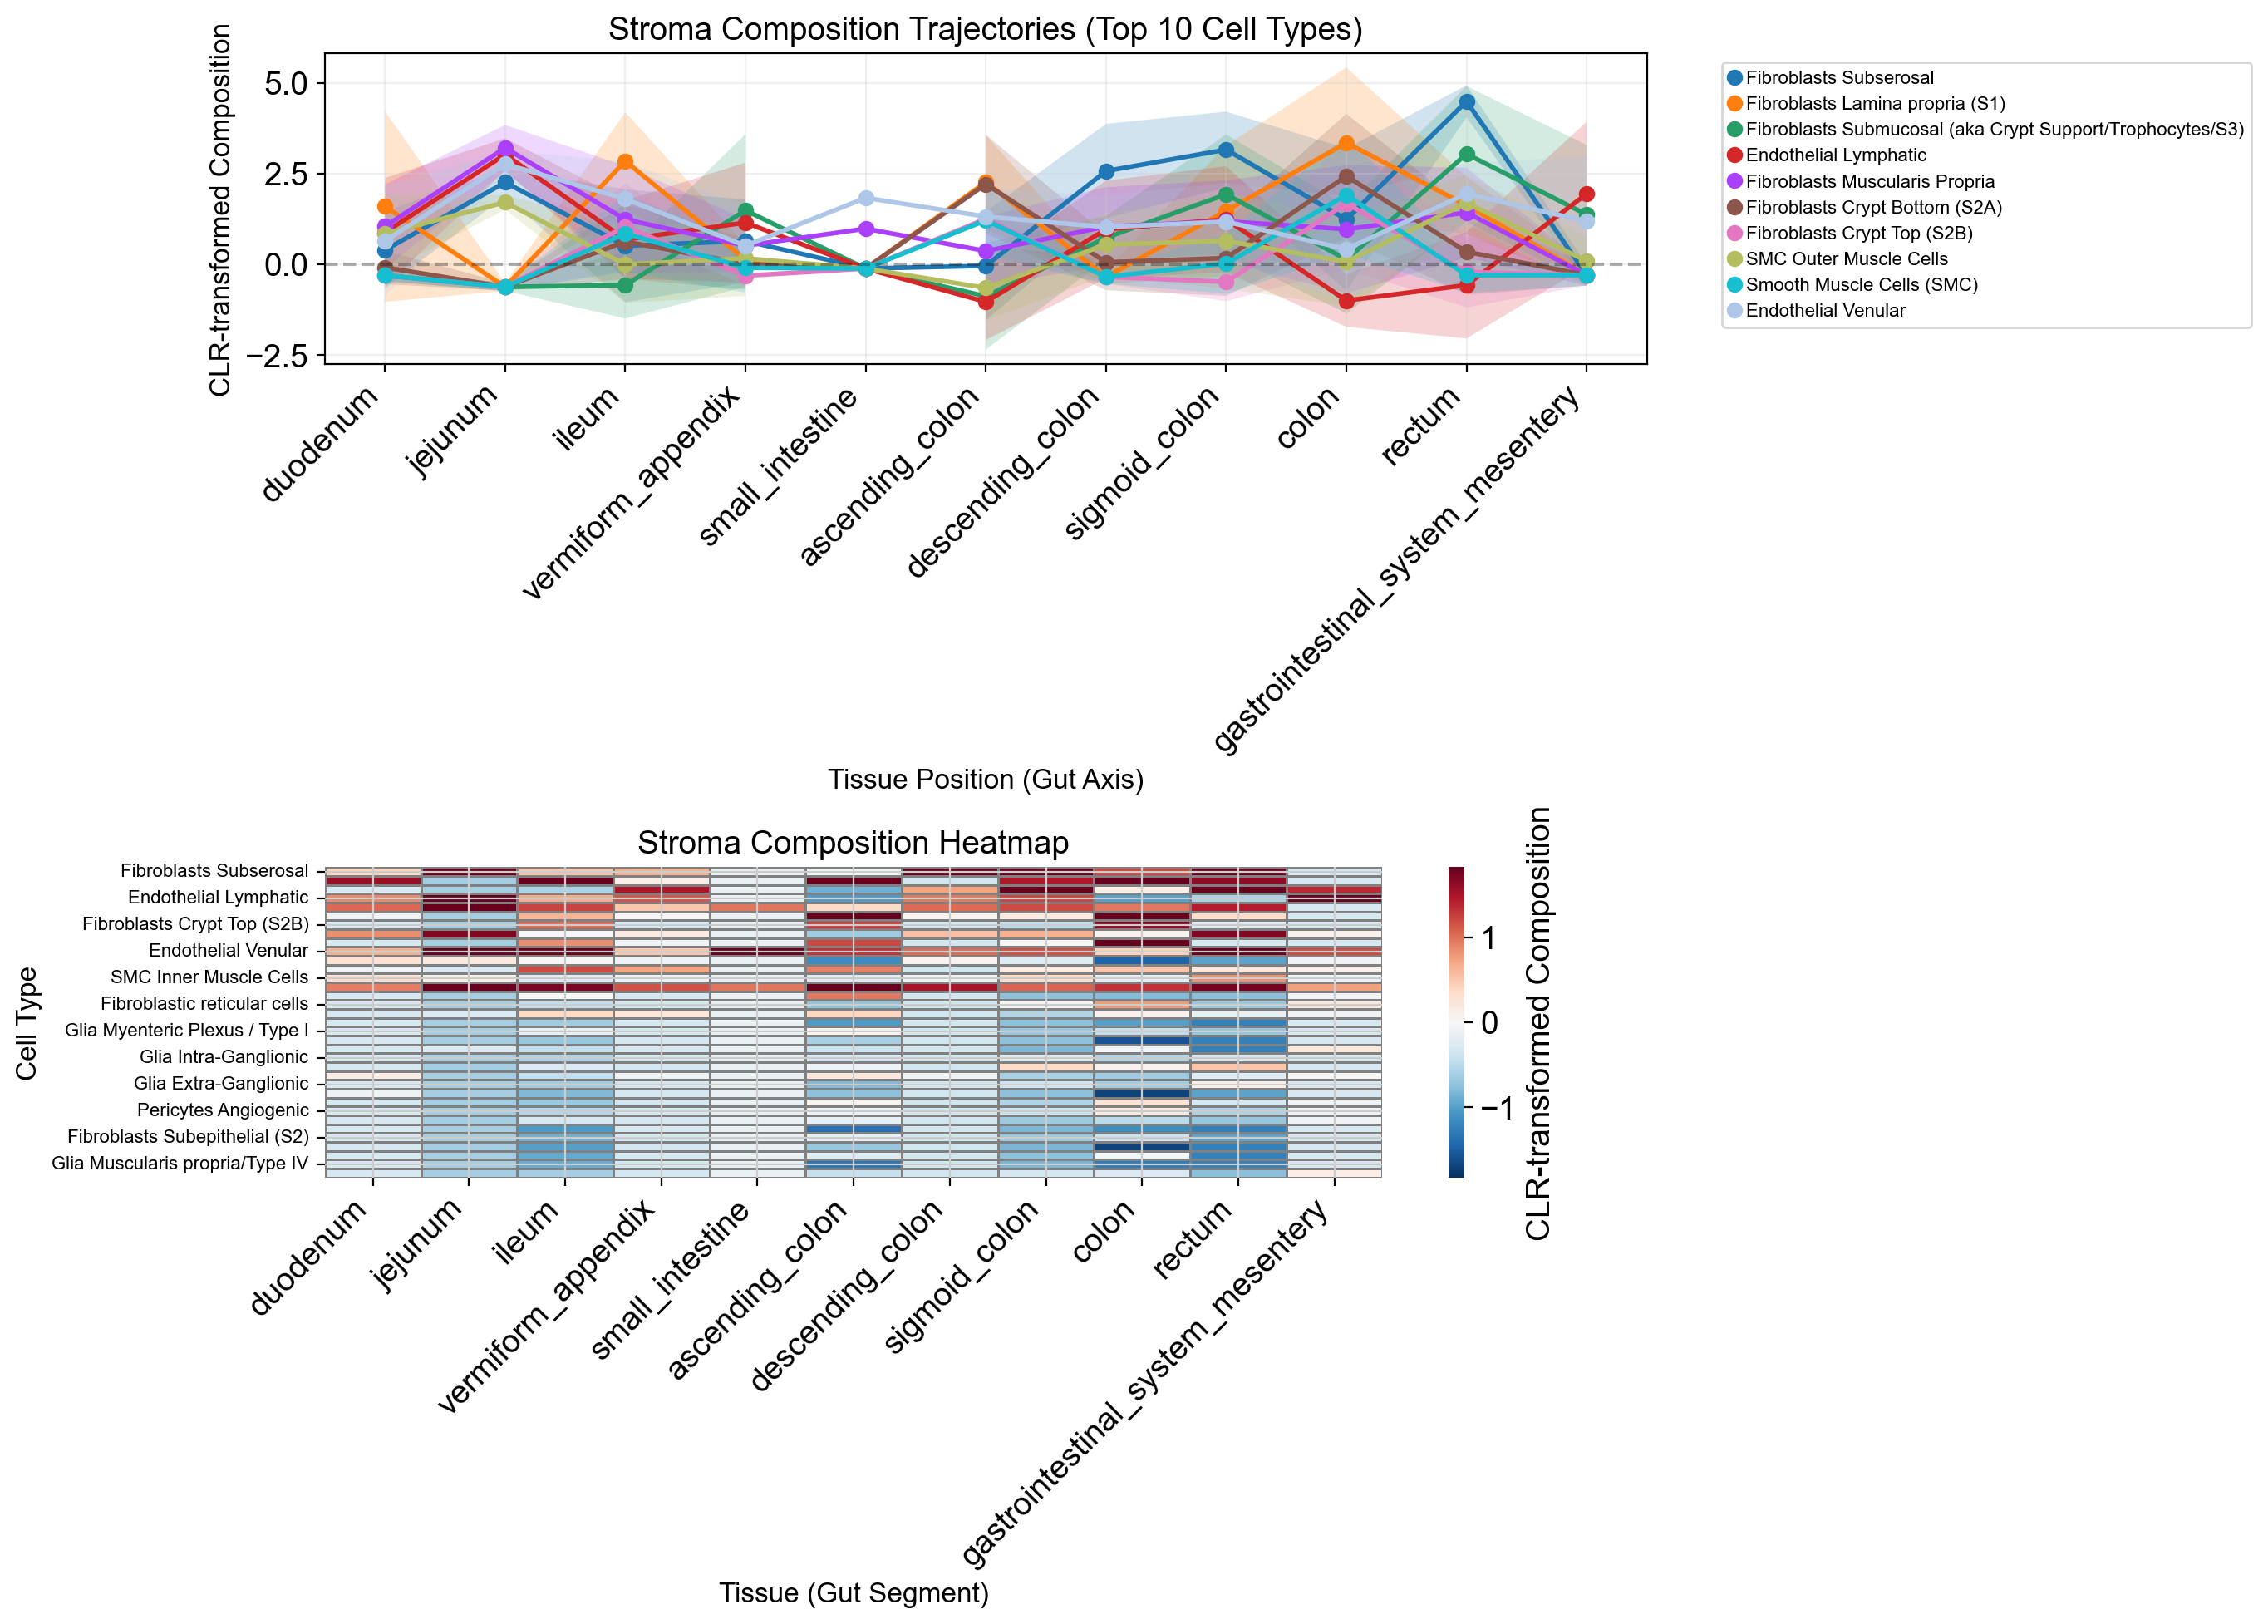

Saved trajectory plot for stroma


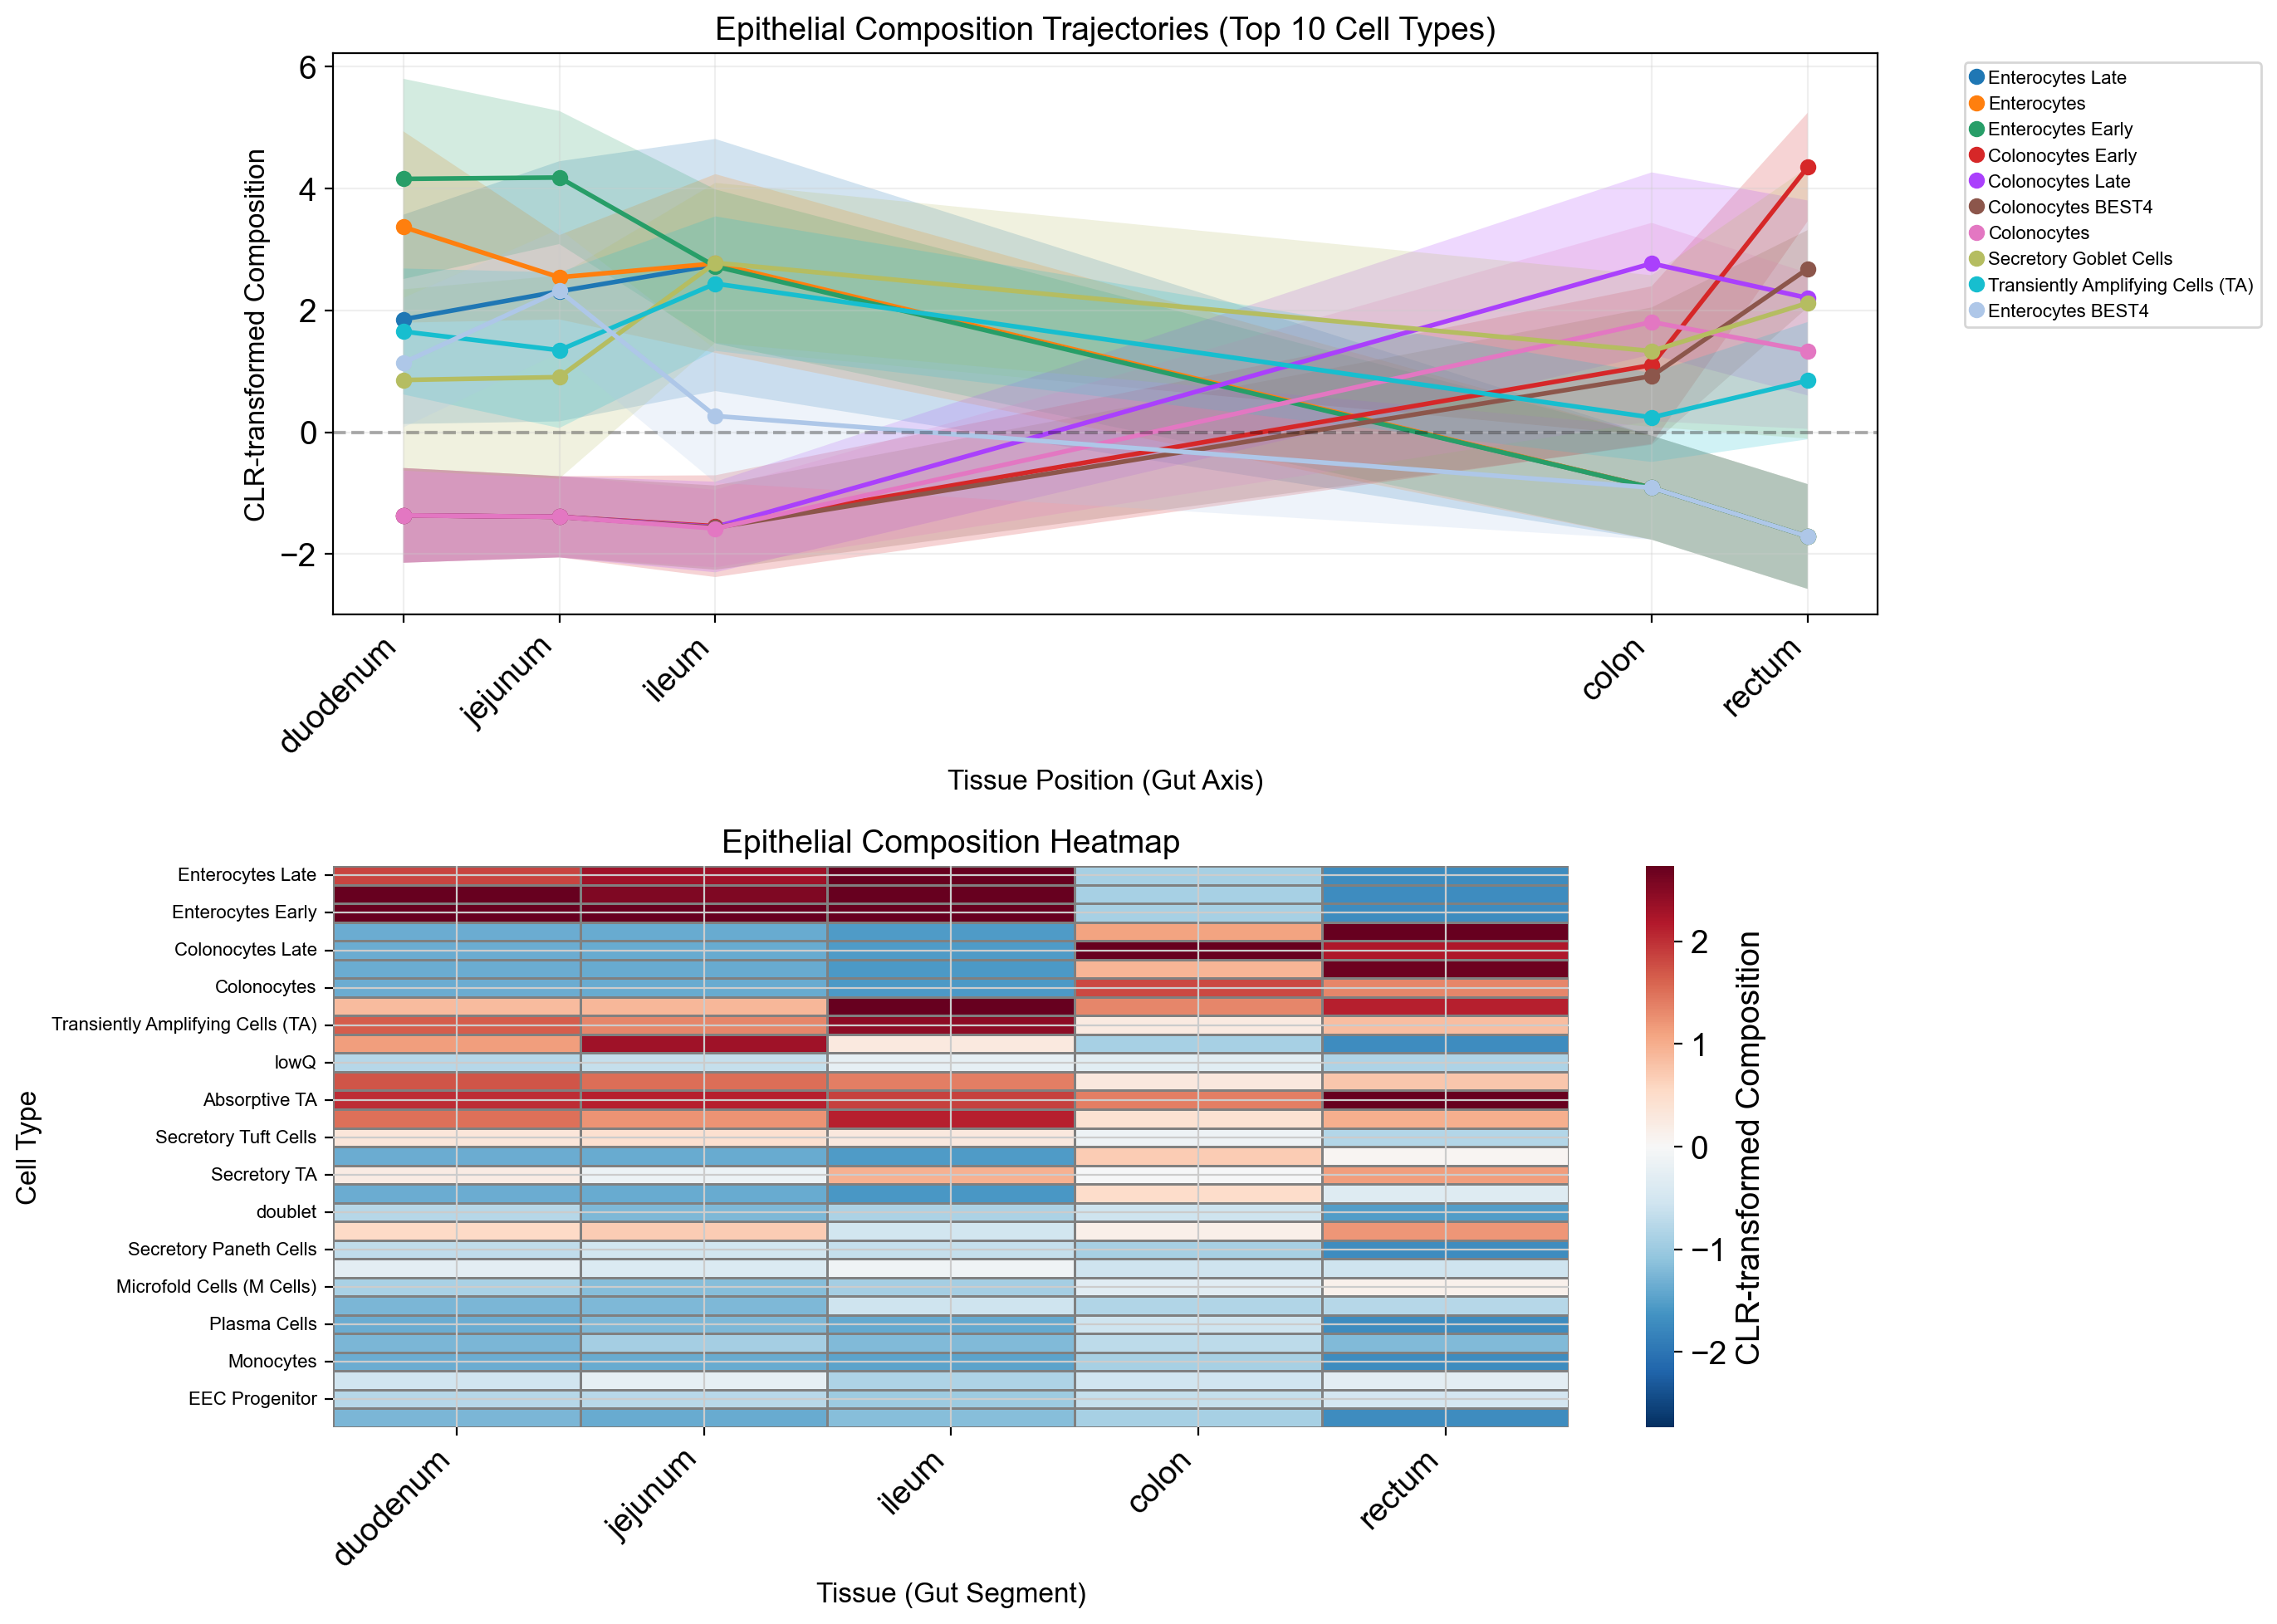

Saved trajectory plot for epithelial


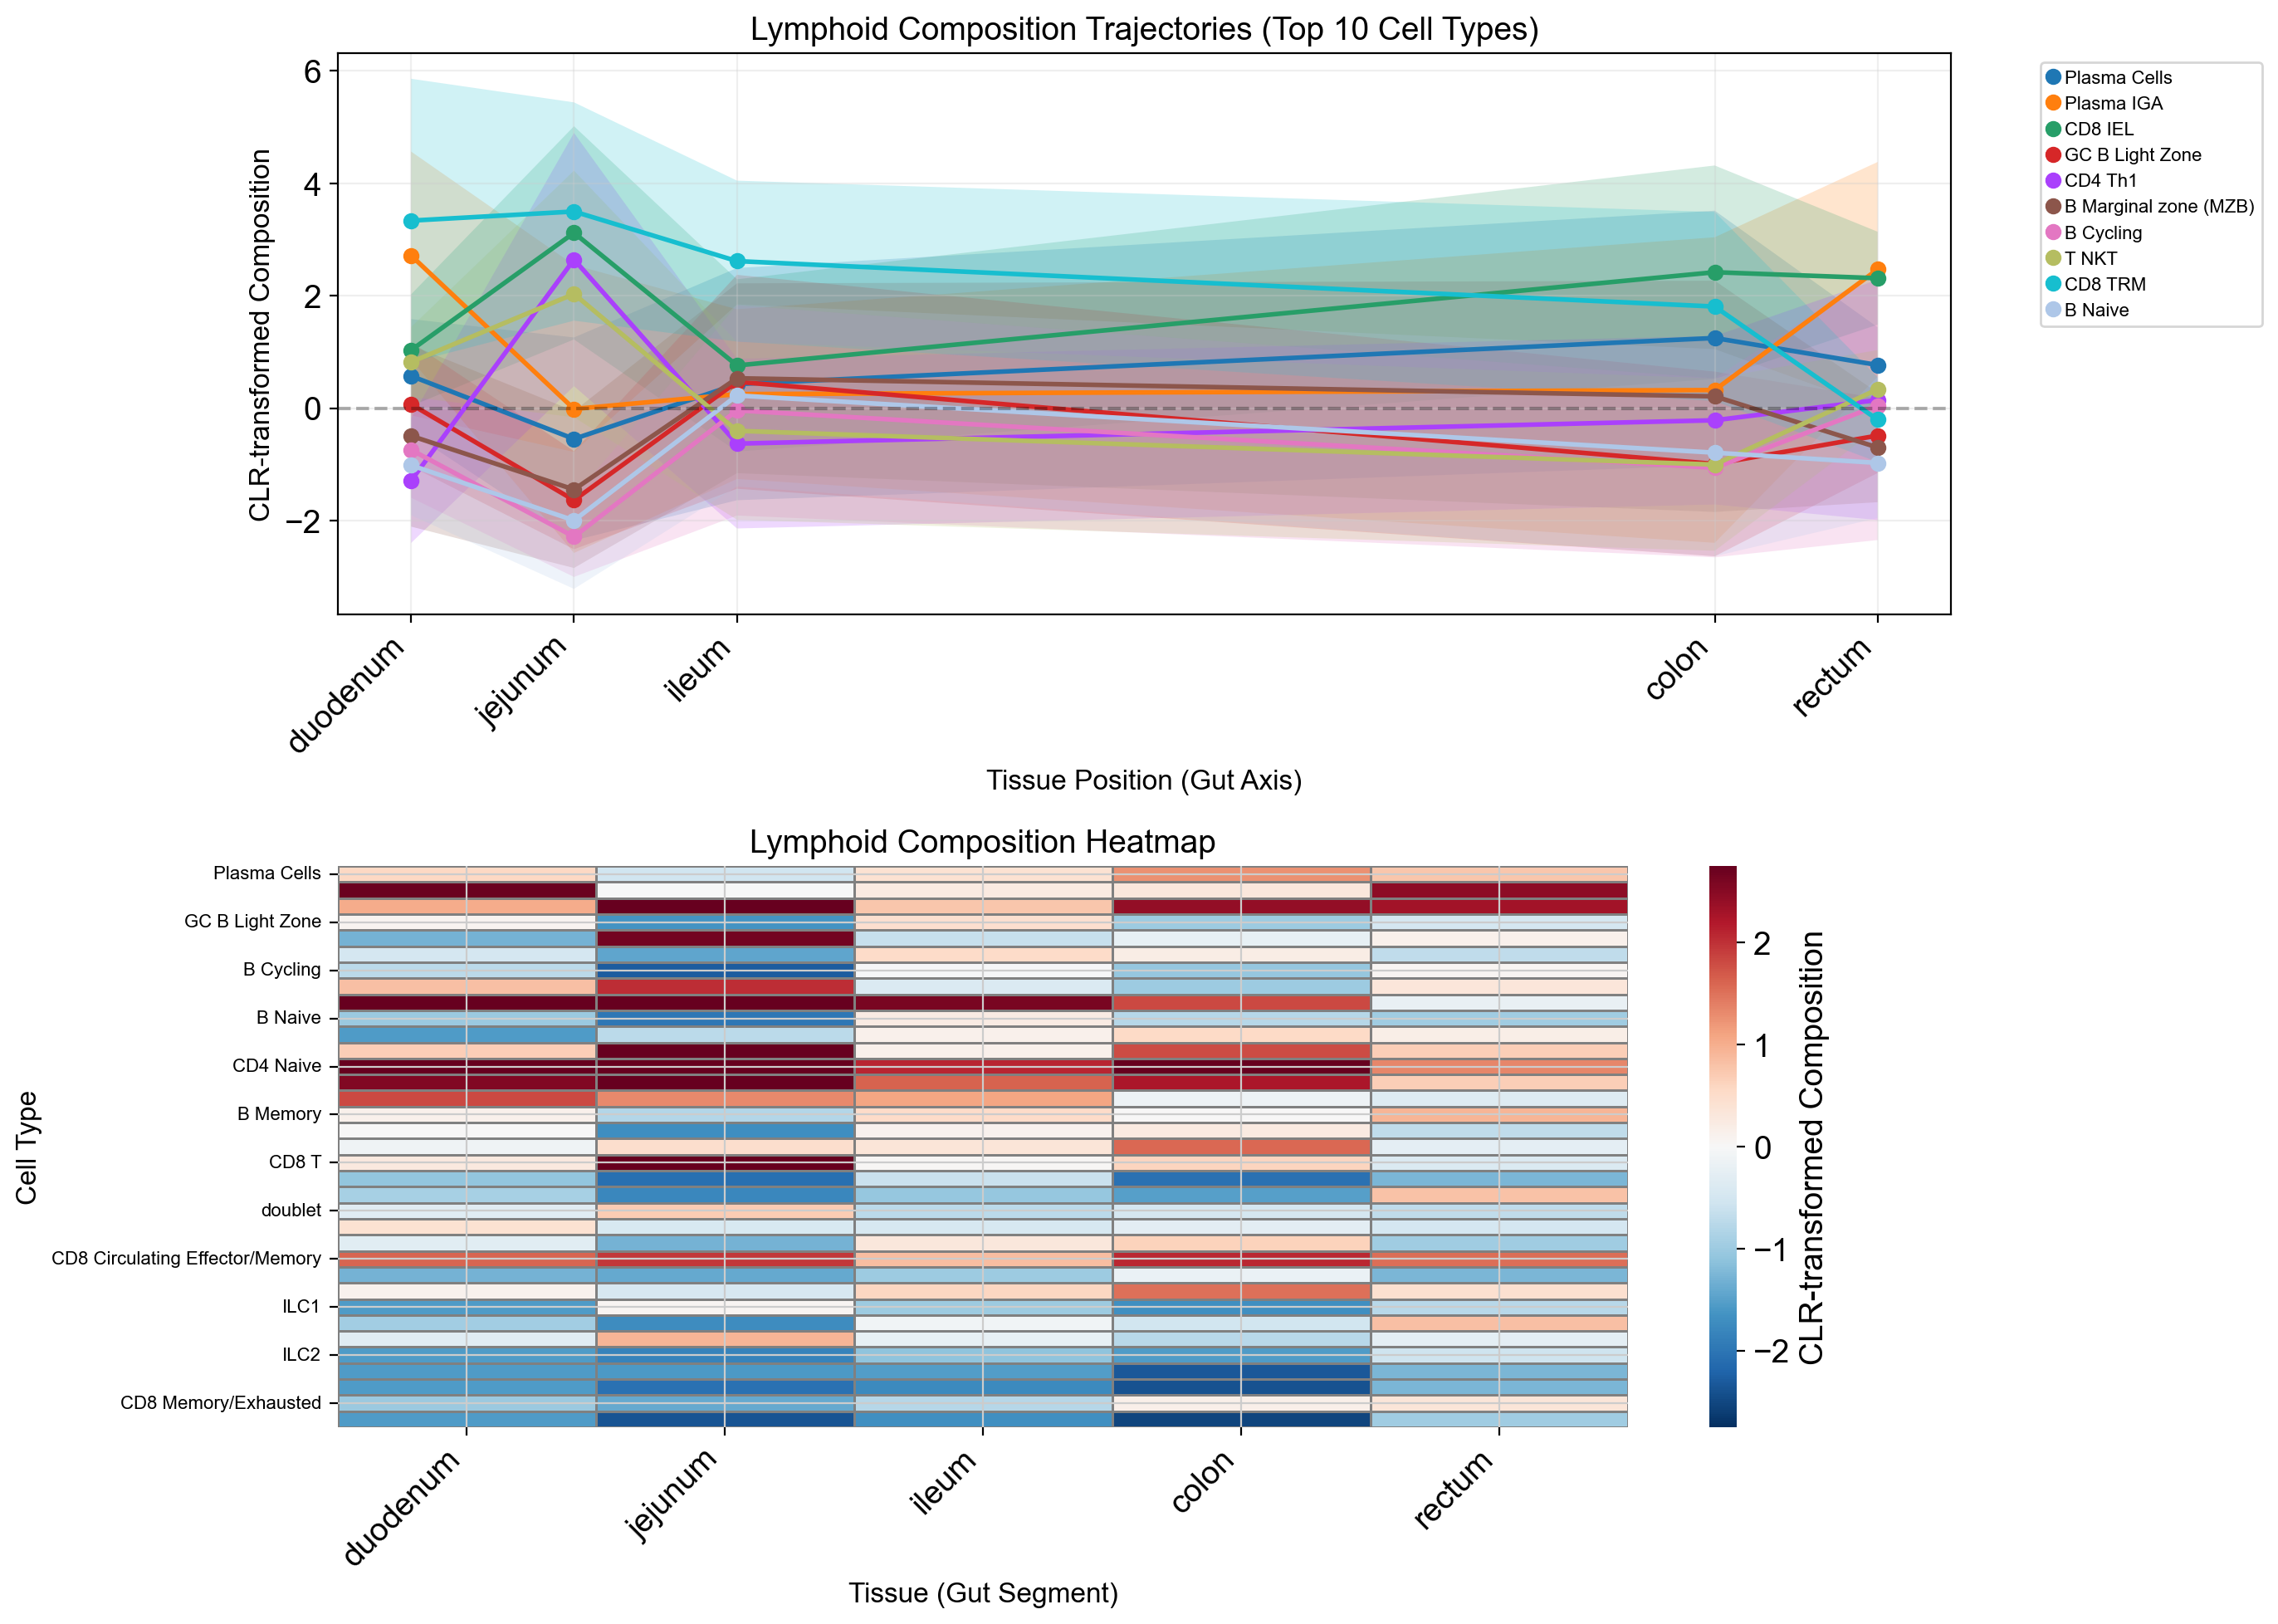

Saved trajectory plot for lymphoid


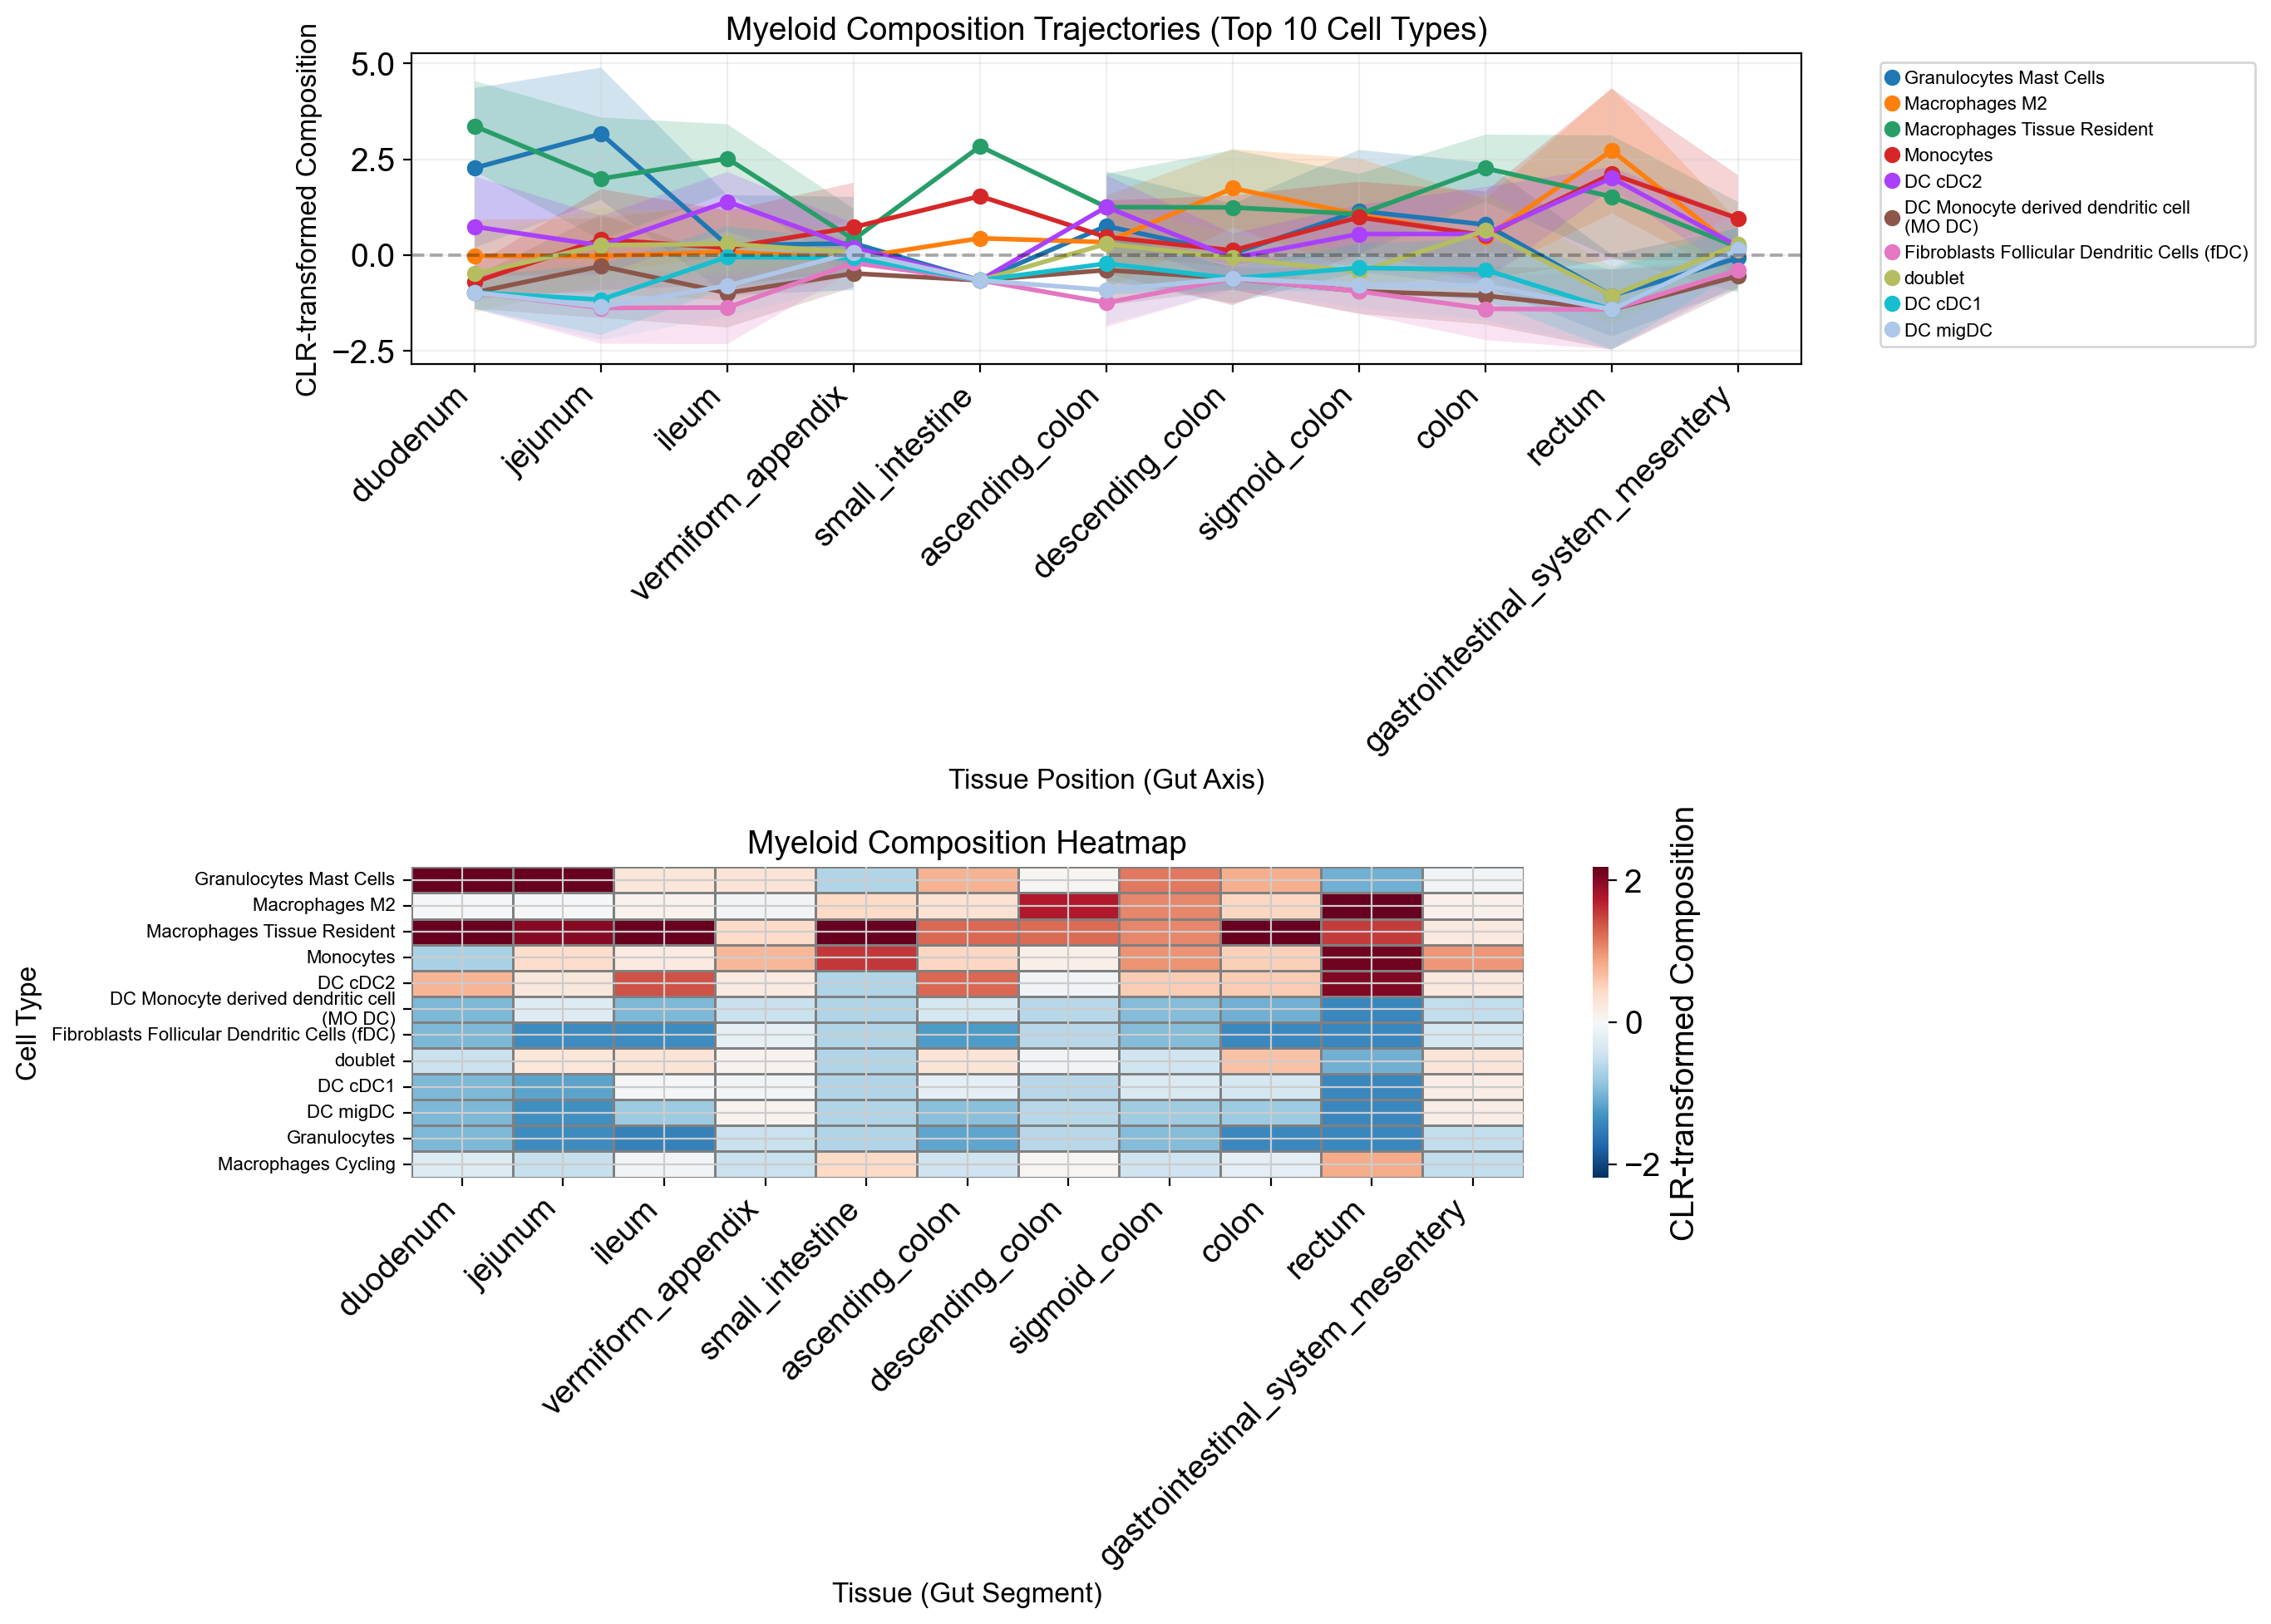

Saved trajectory plot for myeloid


In [ ]:
def plot_composition_trajectories(compositions_dict, lineage_name, top_n=10, output_dir=None):
    """Plot composition trajectories for top N cell types"""
    clr_df = compositions_dict['clr']
    metadata = compositions_dict['metadata']
    
    # Merge with metadata
    clr_with_meta = clr_df.reset_index().merge(
        metadata,
        left_on=metadata.columns[0],
        right_on=metadata.columns[0],
        how='left'
    )
    
    # Filter to valid tissue orders
    clr_with_meta = clr_with_meta[clr_with_meta['tissue_order'] < 999].copy()
    
    # Get actual tissues present in data and create reverse mapping
    present_tissue_orders = sorted(clr_with_meta['tissue_order'].unique())
    order_to_tissue = {order: tissue for tissue, order in tissue_to_order.items()}
    present_tissues = [order_to_tissue.get(order, f'tissue_{order}') for order in present_tissue_orders]
    
    # Select top N cell types by variance across samples
    celltype_variance = clr_df.var().sort_values(ascending=False)
    top_celltypes = celltype_variance.head(top_n).index.tolist()
    
    # Create figure
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: CLR values
    ax1 = axes[0]
    for ct in top_celltypes:
        ct_data = clr_with_meta[['tissue_order', ct]].groupby('tissue_order')[ct].agg(['mean', 'std']).reset_index()
        ct_data = ct_data.sort_values('tissue_order')
        
        ax1.plot(
            ct_data['tissue_order'],
            ct_data['mean'],
            marker='o',
            label=ct,
            linewidth=2,
            markersize=6
        )
        # Add error bars
        ax1.fill_between(
            ct_data['tissue_order'],
            ct_data['mean'] - ct_data['std'],
            ct_data['mean'] + ct_data['std'],
            alpha=0.2
        )
    
    ax1.set_xlabel('Tissue Position (Gut Axis)', fontsize=12)
    ax1.set_ylabel('CLR-transformed Composition', fontsize=12)
    ax1.set_title(f'{lineage_name.capitalize()} Composition Trajectories (Top {top_n} Cell Types)', fontsize=14)
    ax1.set_xticks(present_tissue_orders)
    ax1.set_xticklabels(present_tissues, rotation=45, ha='right')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    
    # Plot 2: Heatmap of all cell types
    ax2 = axes[1]
    
    # Aggregate by tissue
    tissue_clr = clr_with_meta.groupby('tissue_order')[clr_df.columns].mean()
    tissue_clr = tissue_clr.sort_index()
    
    # Reorder columns by variance
    col_order = clr_df.var().sort_values(ascending=False).index.tolist()
    tissue_clr = tissue_clr[col_order]
    
    # Get tissue names for present tissues (matching the heatmap columns)
    present_tissue_names = [order_to_tissue.get(order, f'tissue_{order}') for order in tissue_clr.index]
    
    # Plot heatmap
    vmax = np.nanquantile(np.abs(tissue_clr.values), 0.95)
    sns.heatmap(
        tissue_clr.T,
        cmap='RdBu_r',
        center=0,
        vmin=-vmax,
        vmax=vmax,
        cbar_kws={'label': 'CLR-transformed Composition'},
        ax=ax2,
        linewidths=0.5,
        linecolor='gray'
    )
    
    ax2.set_xlabel('Tissue (Gut Segment)', fontsize=12)
    ax2.set_ylabel('Cell Type', fontsize=12)
    ax2.set_title(f'{lineage_name.capitalize()} Composition Heatmap', fontsize=14)
    ax2.set_xticklabels(present_tissue_names, rotation=45, ha='right')
    plt.setp(ax2.get_yticklabels(), fontsize=8)
    
    plt.tight_layout()
    
    if output_dir:
        fig.savefig(output_dir / f'{lineage_name}_composition_trajectories.png', dpi=300, bbox_inches='tight')
    
    plt.show()
    print(f"Saved trajectory plot for {lineage_name}")

# Create plots for each lineage
for lineage_name, comp_dict in compositions.items():
    plot_composition_trajectories(comp_dict, lineage_name, top_n=10, output_dir=output_dir)

## Quantify Segment Effects on Abundance

Test for segment effects on cell type abundance using per-sample models with optional covariates.

In [19]:
def test_segment_effect_per_sample(clr_df, metadata, covariates=None):
    """
    Test for segment effect on cell type abundance using per-sample CLR values.
    
    Parameters:
    -----------
    clr_df : DataFrame
        CLR-transformed composition (samples x cell types)
    metadata : DataFrame
        Sample metadata including tissue_order
    covariates : list, optional
        List of covariate column names to include in the model
    
    Returns:
    --------
    DataFrame with test results for each cell type
    """
    # Merge with metadata
    data = clr_df.reset_index().merge(
        metadata,
        left_on=metadata.columns[0],
        right_on=metadata.columns[0],
        how='left'
    )
    
    # Filter to valid tissue orders
    data = data[data['tissue_order'] < 999].copy()
    
    if len(data) < 3:
        return pd.DataFrame()
    
    results = []
    
    for ct in clr_df.columns:
        # Prepare features
        X = data[['tissue_order']].values
        y = data[ct].values
        
        # Remove NaN values
        valid_idx = ~np.isnan(y)
        if valid_idx.sum() < 3:
            continue
        
        X = X[valid_idx]
        y = y[valid_idx]
        
        # Add covariates if provided
        if covariates:
            for cov in covariates:
                if cov in data.columns:
                    cov_data = data[cov].values[valid_idx]
                    if pd.api.types.is_categorical_dtype(data[cov]) or data[cov].dtype == 'object':
                        # Encode categorical covariates
                        cov_encoded = pd.get_dummies(pd.Series(cov_data), prefix=cov, drop_first=True)
                        if len(cov_encoded.columns) > 0:
                            X = np.hstack([X, cov_encoded.values])
                    else:
                        # Numeric covariate
                        if not np.all(np.isnan(cov_data)):
                            X = np.hstack([X, cov_data.reshape(-1, 1)])
        
        # Fit linear model
        try:
            model = LinearRegression()
            model.fit(X, y)
            y_pred = model.predict(X)
            
            # Calculate R-squared
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            # Calculate p-value using F-test
            n = len(y)
            p = X.shape[1]
            if n > p:
                f_stat = (r_squared / p) / ((1 - r_squared) / (n - p - 1))
                pvalue = 1 - stats.f.cdf(f_stat, p, n - p - 1)
            else:
                pvalue = np.nan
            
            results.append({
                'celltype': ct,
                'coef': model.coef_[0],  # Coefficient for tissue_order
                'pvalue': pvalue,
                'r_squared': r_squared,
                'n_samples': n
            })
        except:
            continue
    
    return pd.DataFrame(results)

# Test segment effects for each lineage
segment_effects = {}

for lineage_name, comp_dict in compositions.items():
    print(f"\nTesting segment effects for {lineage_name}...")
    
    clr_df = comp_dict['clr']
    metadata = comp_dict['metadata']
    
    # Test without covariates
    results_no_cov = test_segment_effect_per_sample(clr_df, metadata, covariates=None)
    
    # Test with covariates
    covariates = ['assay', 'radial_tissue_term', 'sample_collection_method', 'sampled_site_condition']
    available_covariates = [c for c in covariates if c in metadata.columns]
    
    results_with_cov = test_segment_effect_per_sample(clr_df, metadata, covariates=available_covariates)
    
    # Calculate FDR
    if len(results_no_cov) > 0:
        results_no_cov['fdr'] = multipletests(results_no_cov['pvalue'], method='fdr_bh')[1]
    if len(results_with_cov) > 0:
        results_with_cov['fdr'] = multipletests(results_with_cov['pvalue'], method='fdr_bh')[1]
    
    segment_effects[lineage_name] = {
        'no_covariates': results_no_cov,
        'with_covariates': results_with_cov
    }
    
    print(f"  Tested {len(results_no_cov)} cell types")
    print(f"  Significant effects (FDR < 0.05) without covariates: {np.sum(results_no_cov['fdr'] < 0.05) if len(results_no_cov) > 0 else 0}")
    print(f"  Significant effects (FDR < 0.05) with covariates: {np.sum(results_with_cov['fdr'] < 0.05) if len(results_with_cov) > 0 else 0}")
    
    # Save results
    results_no_cov.to_csv(output_dir / f'{lineage_name}_segment_effects_no_cov.csv', index=False)
    results_with_cov.to_csv(output_dir / f'{lineage_name}_segment_effects_with_cov.csv', index=False)


Testing segment effects for stroma...
  Tested 35 cell types
  Significant effects (FDR < 0.05) without covariates: 15
  Significant effects (FDR < 0.05) with covariates: 30

Testing segment effects for epithelial...
  Tested 30 cell types
  Significant effects (FDR < 0.05) without covariates: 18
  Significant effects (FDR < 0.05) with covariates: 29

Testing segment effects for lymphoid...
  Tested 35 cell types
  Significant effects (FDR < 0.05) without covariates: 21
  Significant effects (FDR < 0.05) with covariates: 35

Testing segment effects for myeloid...
  Tested 12 cell types
  Significant effects (FDR < 0.05) without covariates: 5
  Significant effects (FDR < 0.05) with covariates: 12


## Summary Tables

Create summary tables combining results across lineages.

In [20]:
# Combine segment effect results across lineages
all_results = []

for lineage_name, results_dict in segment_effects.items():
    results = results_dict['with_covariates'].copy()
    if len(results) > 0:
        results['lineage'] = lineage_name
        all_results.append(results)

if len(all_results) > 0:
    combined_results = pd.concat(all_results, ignore_index=True)
    combined_results = combined_results[['lineage', 'celltype', 'coef', 'pvalue', 'fdr', 'r_squared', 'n_samples']]
    combined_results = combined_results.sort_values(['lineage', 'fdr'])
    
    print("Combined segment effect results:")
    print(combined_results.head(20))
    
    # Save combined results
    combined_results.to_csv(output_dir / 'combined_segment_effects.csv', index=False)
    
    # Summary by lineage
    summary = combined_results.groupby('lineage').agg({
        'celltype': 'count',
        'fdr': lambda x: (x < 0.05).sum()
    }).rename(columns={'celltype': 'n_tested', 'fdr': 'n_significant'})
    
    print("\nSummary by lineage:")
    print(summary)
    summary.to_csv(output_dir / 'segment_effects_summary.csv')

Combined segment effect results:
       lineage                              celltype      coef        pvalue  \
36  epithelial                           Colonocytes  0.444676  1.110223e-16   
37  epithelial                     Colonocytes BEST4  0.448544  1.110223e-16   
38  epithelial                     Colonocytes Early  0.590330  1.110223e-16   
39  epithelial                   Colonocytes Laminin  0.244981  1.110223e-16   
40  epithelial                      Colonocytes Late  0.551347  1.110223e-16   
47  epithelial                           Enterocytes -0.643905  1.110223e-16   
48  epithelial                     Enterocytes BEST4 -0.340240  1.110223e-16   
49  epithelial                     Enterocytes Early -0.664429  1.110223e-16   
50  epithelial                      Enterocytes Late -0.626580  1.110223e-16   
55  epithelial                             Monocytes -0.023330  1.110223e-16   
57  epithelial                Secretory Goblet Cells  0.071756  1.110223e-16   
58  epi

## Summary

This notebook has:

1. **Loaded lineage-specific AnnData objects**
2. **Computed coverage tables** showing number of cells, samples, and donors by tissue and assay
3. **Calculated per-sample cell type fractions** with the CLR transformation to handle compositional data
4. **Visualized composition trajectories** along the tissue axis for top cell types
5. **Quantified segment effects** on cell type composition using per-sample models with optional covariates
6. **Exported all tables and plots** to the output directory

The comprehensive tissue coverage and consistent cell type labeling in the healthy gut atlas make this analysis uniquely possible, allowing us to track gradual composition changes along the entire gut axis and compare patterns across lineages.

All outputs have been saved to the `output/composition_along_axis/` directory.